# Estudo de caso - curvas e representação

## Enunciado

Você deve desenhar, em uma matriz **20 × 12** de LEDs (origem no canto **inferior esquerdo**), um mini-logo composto por:

1) Um arco superior modelado por **uma Bézier cúbica**.  
2) Uma “calda” à direita modelada por **uma B-spline cúbica**.  
3) A curva inteira deve virar pixels acesos usando o **algoritmo de rasterização por ponto médio** para **segmentos de reta** (polilinha obtida amostrando as curvas).

### Dados

**Bézier cúbica (arco)**  
Pontos de controle:
$$
P_0=(2,2),\quad P_1=(4,6),\quad P_2=(8,6),\quad P_3=(10,2).
$$

**B-spline cúbica (calda)**  
Pontos de controle:
$$
Q_0=(10,2),\quad Q_1=(12,1),\quad Q_2=(14,3),\quad Q_3=(16,2),\quad Q_4=(18,2),
$$
grau $p=3$ e **vetor de nós aberto uniforme** com 1 nó interno:
$$
U=[0,0,0,0,\;0.5,\;1,1,1,1].
$$

### Tarefas

**(a)** Avaliar a Bézier em $t=0,\,0.25,\,0.5,\,0.75,\,1$; mostrar as contas dos **pesos de Bernstein** e dos pontos $\mathbf{B}(t)$.  
**(b)** Avaliar a B-spline em $u=0.25,\,0.5,\,0.75$ via **De Boor**; mostrar **um cálculo completo** (em $u=0.25$) com os $\alpha$.  
**(c)** Quantizar (arredondar) todos os pontos para a grade de pixels e **conectar** amostras consecutivas.  
**(d)** Rasterizar com **ponto médio** dois segmentos passo a passo; listar os pixels dos demais.  
**(e)** Apresentar a **lista final** de pixels a acender.

---

## Resolução detalhada

### (a) Bézier cúbica — polinômios de Bernstein

Fórmula (grau 3):
$$
\mathbf{B}(t)=(1-t)^3P_0+3(1-t)^2t\,P_1+3(1-t)t^2\,P_2+t^3P_3.
$$

Pesos de Bernstein:
$$
b_0=(1-t)^3,\quad b_1=3(1-t)^2t,\quad b_2=3(1-t)t^2,\quad b_3=t^3.
$$

#### 1) $t=0$
$$
b_0=1,\;b_1=b_2=b_3=0\ \Rightarrow\ \mathbf{B}(0)=P_0=(2,2).
$$

#### 2) $t=0.25$ (logo, $1-t=0.75$)
$$
\begin{aligned}
&b_0=0.75^3=0.421875, \\
&b_1=3\cdot 0.75^2\cdot 0.25=3\cdot 0.5625\cdot 0.25=0.421875,\\
&b_2=3\cdot 0.75\cdot 0.25^2=3\cdot 0.75\cdot 0.0625=0.140625,\\
&b_3=0.25^3=0.015625.
\end{aligned}
$$

Coordenadas:
$$
\begin{aligned}
x &= 0.421875\cdot 2+0.421875\cdot 4+0.140625\cdot 8+0.015625\cdot 10\\
  &= 0.84375+1.6875+1.125+0.15625=\mathbf{3.8125},\\[4pt]
y &= 0.421875\cdot 2+0.421875\cdot 6+0.140625\cdot 6+0.015625\cdot 2\\
  &= 0.84375+2.53125+0.84375+0.03125=\mathbf{4.25}.
\end{aligned}
$$

$\Rightarrow\ \boxed{\mathbf{B}(0.25)=(3.8125,\ 4.25)}$.

#### 3) $t=0.5$ ($1-t=0.5$)
$$
b_0=b_3=0.5^3=0.125,\qquad b_1=b_2=3\cdot 0.5^2\cdot 0.5=0.375.
$$
$$
\begin{aligned}
x &= 0.125\cdot 2+0.375\cdot 4+0.375\cdot 8+0.125\cdot 10=6.0,\\
y &= 0.125\cdot 2+0.375\cdot 6+0.375\cdot 6+0.125\cdot 2=5.0.
\end{aligned}
$$

$\Rightarrow\ \boxed{\mathbf{B}(0.5)=(6.0,\ 5.0)}$.

#### 4) $t=0.75$ ($1-t=0.25$)
$$
\begin{aligned}
&b_0=0.015625,\quad b_1=0.140625,\quad b_2=0.421875,\quad b_3=0.421875,\\
&x=0.015625\cdot 2+0.140625\cdot 4+0.421875\cdot 8+0.421875\cdot 10=\mathbf{8.1875},\\
&y=0.015625\cdot 2+0.140625\cdot 6+0.421875\cdot 6+0.421875\cdot 2=\mathbf{4.25}.
\end{aligned}
$$

$\Rightarrow\ \boxed{\mathbf{B}(0.75)=(8.1875,\ 4.25)}$.

#### 5) $t=1$
$$
b_3=1,\ b_0=b_1=b_2=0\ \Rightarrow\ \mathbf{B}(1)=P_3=(10,2).
$$

---

### (b) B-spline cúbica — algoritmo de **De Boor**

**Vetor de nós aberto uniforme:** garante que a curva interpola $Q_0$ e $Q_4$.  
**Span $k$:** é tal que $U_k \le u < U_{k+1}$.  
Para grau $p=3$, participam 4 pontos: $Q_{k-3},Q_{k-2},Q_{k-1},Q_k$.

**Fórmula de atualização:**
$$
d_j \leftarrow (1-\alpha)\,d_{j-1}+\alpha\,d_j,\quad
\alpha=\frac{u-U_i}{U_{i+p+1-r}-U_i}.
$$

#### (i) u=0.25
Span: $U_3=0 \le 0.25 < 0.5=U_4 \Rightarrow k=3$.

Inicial:
$$
d_0=Q_0=(10,2),\ d_1=Q_1=(12,1),\ d_2=Q_2=(14,3),\ d_3=Q_3=(16,2).
$$

**r=1**
- j=3, i=3: α=0.25 → d3=(14.5,2.75)
- j=2, i=2: α=0.25 → d2=(12.5,1.5)
- j=1, i=1: α=0.5 → d1=(11.0,1.5)

**r=2**
- j=3, i=3: α=0.25 → d3=(13.0,1.8125)
- j=2, i=2: α=0.5 → d2=(11.75,1.5)

**r=3**
- j=3, i=3: α=0.5 → d3=(12.375,1.65625)

$\Rightarrow \mathbf{C}(0.25)=(12.375,1.65625)$

---

### (c) Quantização para a grade

**Bézier:** (2,2),(4,4),(6,5),(8,4),(10,2)  
**B-spline:** (10,2),(12,2),(14,2),(16,2),(18,2)

---

### (d) Rasterização por ponto médio

Exemplo: (4,4)→(6,5)
$$
\Delta x=2,\ \Delta y=1,\ d_0=0.
$$
- Start (4,4): d>=0 ⇒ NE → (5,5), d←-2
- d<0 ⇒ E → (6,5)

Exemplo: (6,5)→(8,4) (declive negativo)
Espelhar y: (6,-5)→(8,-4), rasterizar igual e refletir de volta:
Pixels: (6,5),(7,4),(8,4)

---

### (e) Lista final de pixels

(2,2),(3,3),(4,4),(5,5),(6,5),(7,4),(8,4),(9,3),(10,2),
(11,2),(12,2),(13,2),(14,2),(15,2),(16,2),(17,2),(18,2)


=== Bézier cúbica (amostras t) ===
t = [0.0, 0.25, 0.5, 0.75, 1.0]
B(t) = (2, 2), (3.812, 4.25), (6, 5), (8.188, 4.25), (10, 2)

=== B-spline cúbica (De Boor) ===
u = [0.0, 0.25, 0.5, 0.75, 1.0]
C(u) = (10, 2), (12.38, 1.656), (14, 2.25), (15.62, 2.219), (18, 2)

=== Quantização (pontos da polilinha) ===
Polyline quantizada: [[2, 2], [4, 4], [6, 5], [8, 4], [10, 2], [12, 2], [14, 2], [16, 2], [18, 2]]

=== Pixels rasterizados (ordem de acendimento) ===
[(2, 2), (3, 3), (4, 4), (5, 5), (6, 5), (7, 4), (8, 4), (9, 3), (10, 2), (11, 2), (12, 2), (13, 2), (14, 2), (15, 2), (16, 2), (17, 2), (18, 2)]


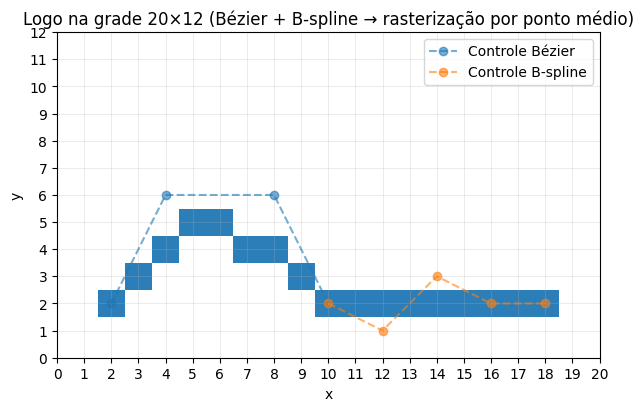

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) DADOS DO PROBLEMA
# ============================================================

# Bézier cúbica (arco)
P0 = np.array([2.0, 2.0])
P1 = np.array([4.0, 6.0])
P2 = np.array([8.0, 6.0])
P3 = np.array([10.0, 2.0])
P_bezier = np.vstack([P0, P1, P2, P3])

# B-spline cúbica (calda) - vetor de nós aberto uniforme com 1 nó interno em 0.5
Q = np.array([
    [10.0, 2.0],
    [12.0, 1.0],
    [14.0, 3.0],
    [16.0, 2.0],
    [18.0, 2.0],
])
p = 3
U = np.array([0.0,0.0,0.0,0.0, 0.5, 1.0,1.0,1.0,1.0])  # tamanho n+p+2 = 5+3+1=9

# ============================================================
# 2) BÉZIER CÚBICA (Bernstein)
# ============================================================

def bezier_cubic(P, t):
    """
    Curva de Bézier cúbica via polinômios de Bernstein.
    P: array shape (4,2)
    t: escalar ou array em [0,1]
    retorna array shape (len(t), 2)
    """
    t = np.atleast_1d(t).astype(float)
    one_t = 1.0 - t
    B = (one_t**3)[:, None]*P[0] \
        + (3*one_t**2*t)[:, None]*P[1] \
        + (3*one_t*t**2)[:, None]*P[2] \
        + (t**3)[:, None]*P[3]
    return B

# Avaliar nos t pedidos (inclusive extremos)
t_samples = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
B_pts = bezier_cubic(P_bezier, t_samples)

# ============================================================
# 3) B-SPLINE CÚBICA (De Boor em nó aberto uniforme)
# ============================================================

def find_knot_span(u, U, p, n):
    """
    Retorna o índice k do span tal que U[k] <= u < U[k+1].
    Convenção: se u == U[n+1] (último válido), retorna k=n.
    n = número de pontos de controle - 1
    """
    if u >= U[n+1]:  # no extremo direito
        return n
    # busca binária simples
    low, high = p, n+1
    k = (low + high) // 2
    while not (U[k] <= u < U[k+1]):
        if u < U[k]:
            high = k
        else:
            low = k
        k = (low + high) // 2
    return k

def de_boor(u, p, U, Q):
    """
    Algoritmo de De Boor para avaliar B-spline.
    u: parâmetro
    p: grau
    U: vetor de nós (len = n+p+2)
    Q: pontos de controle (shape (n+1, 2))
    Retorna ponto C(u) (2D)
    """
    n = Q.shape[0] - 1
    k = find_knot_span(u, U, p, n)

    # inicialização com os p+1 pontos locais
    d = [Q[k - p + j].astype(float).copy() for j in range(p+1)]

    # r = 1..p rodadas de interpolações
    for r in range(1, p+1):
        for j in range(p, r-1, -1):
            i = k - p + j
            denom = (U[i + p + 1 - r] - U[i])
            # evitar divisão por zero em nós repetidos (alpha=0)
            alpha = 0.0 if denom == 0.0 else (u - U[i]) / denom
            d[j] = (1.0 - alpha) * d[j-1] + alpha * d[j]
    return d[p]

# Avaliar nos u pedidos
u_samples = np.array([0.25, 0.5, 0.75])
C_pts = np.vstack([de_boor(u, p, U, Q) for u in u_samples])

# Para referência (extremos da curva B-spline)
C_start = Q[0]     # por nó aberto: C(0) = Q0
C_end   = Q[-1]    # por nó aberto: C(1) = Qn

# ============================================================
# 4) QUANTIZAÇÃO (arredondar para grade 20x12)
# ============================================================

def quantize_points(pts):
    """Arredonda coordenadas para o inteiro mais próximo."""
    return np.rint(pts).astype(int)

# pontos quantizados (Bézier e B-spline)
B_pix = quantize_points(B_pts)
C_pix = quantize_points(np.vstack([C_start, C_pts, C_end]))

# Conectar em polilinha única (evitando duplicar o (10,2) na junção)
polyline = np.vstack([B_pix, C_pix[1:]])

# ============================================================
# 5) RASTERIZAÇÃO POR PONTO MÉDIO (Bresenham, todos os octantes)
# ============================================================

def rasterize_segment(p0, p1):
    """
    Rasteriza um segmento de reta entre p0=(x0,y0) e p1=(x1,y1)
    usando o algoritmo de ponto médio (Bresenham) em todos os octantes.
    Retorna lista de pares (x,y) inteiros incluindo extremos.
    """
    x0, y0 = map(int, p0)
    x1, y1 = map(int, p1)

    # Diferenças
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)

    # Direções de incremento
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1

    points = []

    # Caso "não-íngreme" (|dx| >= |dy|)
    if dx >= dy:
        err = 2*dy - dx
        x, y = x0, y0
        for _ in range(dx + 1):
            points.append((x, y))
            if err >= 0:
                y += sy
                err -= 2*dx
            err += 2*dy
            x += sx
    else:
        # Caso "íngreme" (|dy| > |dx|): trocamos papel de x e y
        err = 2*dx - dy
        x, y = x0, y0
        for _ in range(dy + 1):
            points.append((x, y))
            if err >= 0:
                x += sx
                err -= 2*dy
            err += 2*dx
            y += sy

    return points

# Rasterizar toda a polilinha
pixels = []
for i in range(len(polyline)-1):
    seg_pixels = rasterize_segment(polyline[i], polyline[i+1])
    if i > 0:
        # evitar duplicar o primeiro pixel do segmento (junção)
        seg_pixels = seg_pixels[1:]
    pixels.extend(seg_pixels)

# Remover quaisquer duplicatas preservando ordem (segurança)
seen = set()
pixels_unique = []
for xy in pixels:
    if xy not in seen:
        pixels_unique.append(xy)
        seen.add(xy)

# ============================================================
# 6) RELATÓRIO NUMÉRICO
# ============================================================

def fmt_points(arr):
    return ", ".join([f"({x:.4g}, {y:.4g})" for x,y in arr])

print("=== Bézier cúbica (amostras t) ===")
print("t =", t_samples.tolist())
print("B(t) =", fmt_points(B_pts))
print()
print("=== B-spline cúbica (De Boor) ===")
print("u =", [0.0] + u_samples.tolist() + [1.0])
print("C(u) =", fmt_points(np.vstack([C_start, C_pts, C_end])))
print()
print("=== Quantização (pontos da polilinha) ===")
print("Polyline quantizada:", polyline.tolist())
print()
print("=== Pixels rasterizados (ordem de acendimento) ===")
print(pixels_unique)

# ============================================================
# 7) PLOTAR MATRIZ 20x12 COM PIXELS ACESOS
# ============================================================

def plot_matrix(pixels_on, P_bezier=None, Q_spline=None):
    W, H = 20, 12
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.set_xlim(0, W)
    ax.set_ylim(0, H)
    ax.set_aspect('equal', adjustable='box')

    # grade
    ax.set_xticks(range(0, W+1))
    ax.set_yticks(range(0, H+1))
    ax.grid(True, which='both', linewidth=0.5, alpha=0.35)

    # desenhar "LEDs" como quadrados
    for (x, y) in pixels_on:
        if 0 <= x <= W and 0 <= y <= H:
            ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1, alpha=0.95))

    # polígonos de controle (opcional, para visualizar)
    if P_bezier is not None:
        ax.plot(P_bezier[:,0], P_bezier[:,1], '--o', alpha=0.6, label='Controle Bézier')
    if Q_spline is not None:
        ax.plot(Q_spline[:,0], Q_spline[:,1], '--o', alpha=0.6, label='Controle B-spline')

    ax.set_title("Logo na grade 20×12 (Bézier + B-spline → rasterização por ponto médio)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="upper right")
    plt.show()

plot_matrix(pixels_unique, P_bezier=P_bezier, Q_spline=Q)


# 📘 Explicação Detalhada do Código

Este notebook calcula e desenha um logo formado por uma curva **Bézier cúbica** e uma **B-spline cúbica**, depois converte em pixels usando **rasterização por ponto médio**.

---

## 1. Dados do Problema

Primeiro definimos os pontos de controle:

- **Bézier:**  
$$P_0=(2,2),\ P_1=(4,6),\ P_2=(8,6),\ P_3=(10,2)$$

- **B-spline:**  
$$Q_0=(10,2),\ Q_1=(12,1),\ Q_2=(14,3),\ Q_3=(16,2),\ Q_4=(18,2)$$

A B-spline é de grau $$p=3$$ (cúbica) e usa vetor de nós aberto uniforme:

$$U=[0,0,0,0,\ 0.5,\ 1,1,1,1]$$

Os quatro zeros e quatro uns garantem que a curva passe exatamente por $Q_0$ e $Q_4$.

---

## 2. Bézier Cúbica com Polinômios de Bernstein

A função `bezier_cubic` implementa a fórmula:

$$
\mathbf{B}(t)=(1-t)^3P_0+3(1-t)^2tP_1+3(1-t)t^2P_2+t^3P_3
$$

O código cria os vetores de pesos $b_0,b_1,b_2,b_3$ para todos os $t$ de uma vez (usando broadcasting do NumPy) e retorna os pontos resultantes.

No notebook, avaliamos para:

$$t=0,\ 0.25,\ 0.5,\ 0.75,\ 1.0$$

e obtemos cinco pontos que formam o arco superior.

---

## 3. B-spline Cúbica via Algoritmo de De Boor

### 3.1 Encontrar o Span

O "span" é o índice $k$ tal que:

$$U_k \le u < U_{k+1}$$

Ele diz qual intervalo de nós contém o parâmetro $u$ e quais pontos de controle vão influenciar a curva. Para grau cúbico usamos $p+1=4$ pontos locais: $Q_{k-3},Q_{k-2},Q_{k-1},Q_k$.

### 3.2 Interpolação Recursiva

A função `de_boor` pega esses pontos e faz $p$ rodadas de interpolação linear usando:

$$
d_j \leftarrow (1-\alpha)d_{j-1} + \alpha d_j,\quad
\alpha = \frac{u - U_i}{U_{i+p+1-r}-U_i}
$$

Cada rodada aproxima os pontos e, no final, sobra um único ponto $d_p$, que é $\mathbf{C}(u)$.

Avaliamos em:

$$u=0.25,\ 0.5,\ 0.75$$

para formar a “calda”.

---

## 4. Quantização para a Grade

Os pontos contínuos são arredondados com `np.rint` para cair na grade 20×12 (inteiros). A Bézier e a B-spline se unem formando uma **polilinha** sem repetir o ponto de junção $(10,2)$.

---

## 5. Rasterização por Ponto Médio

Cada segmento da polilinha é convertido em pixels com o algoritmo de ponto médio (Bresenham):

- Calcula-se $$\Delta x=x_1-x_0$$ e $$\Delta y=y_1-y_0$$
- Define-se o erro inicial: $$d_0=2\Delta y-\Delta x$$
- A cada passo:
  - Se $d \ge 0$: escolhe NE (x+1,y+1) e ajusta $d$
  - Se $d < 0$: escolhe E (x+1,y) e ajusta $d$

Esse processo funciona para qualquer octante (subida, descida ou horizontal).

---

## 6. Lista Final de Pixels

Todos os pixels são armazenados, duplicatas removidas e impressos em ordem para você acender os LEDs na sequência correta.

---

## 7. Plotagem

Por fim, a função `plot_matrix` cria uma figura com grade 20×12, desenha os pixels como quadrados preenchidos e opcionalmente plota os polígonos de controle (em tracejado).

---

## Resumo

1. **Curvas contínuas:** calculadas com fórmulas exatas.  
2. **Amostragem:** pega pontos representativos.  
3. **Quantização:** converte para coordenadas inteiras.  
4. **Rasterização:** liga os pontos sem buracos.  
5. **Visualização:** mostra o resultado na matriz de LEDs.

Esse pipeline garante que a curva seja representada corretamente em hardware discreto (matriz de LEDs).




---

